In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import warnings, os, gc, re
import matplotlib.pyplot as plt
import psutil
import swifter
# import icd10
from ast import literal_eval

# from plotnine import ggplot, aes, geom_line
from plotnine import *
# import pygal as pg

%matplotlib inline

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

In [2]:
# count number of rows
from itertools import (takewhile,repeat)
def rawincount(filename):
    f = open(filename, 'rb')
    bufgen = takewhile(lambda x: x, (f.raw.read(1024*1024) for _ in repeat(None)))
    return sum( buf.count(b'\n') for buf in bufgen )

### Remove carriage returns for the files

In [ ]:
# DO NOT EXECUTE ANYMORE - ROWS CLEANED OF CARRIAGE RETURN ALREADY
# path, dirs, files = next(os.walk("chunks/"))
# file_count = len(files)
# year_start = 2013
# year_end = 2020

# for i in range(year_start, year_end+1):
#     directory = 'chunks/'
#     print(i)
#     print('total count:', rawincount(os.path.join(directory, str(i) + '_new.csv')))
#     df1 = pd.read_csv(os.path.join(directory, str(i) + '_new.csv'), low_memory=False)
#     df1['ILLNESS1_DESC'] = df1['ILLNESS1_DESC'].str.replace(r'\n','')
#     df1.to_csv(os.path.join(directory, str(i) + '_new_1.csv'), index=False)
#     del[df1]
#     gc.collect()    

### Parm LIb declarations

In [3]:
path, dirs, files = next(os.walk("chunks/"))
directory = 'chunks/'
file_count = len(files)
year_start = 2013
year_end = 2020

In [4]:
# codes in ILLNESS*_CODE that are not ICD-10 codes
not_icd = ['MCP01', 'NSD01', 'P0000', 'P0001', 'ANC01', 'ANC02', 'FP001',
          'C19CI', 'C19CIS', 'C19FRP', 'C19IP1', 'C19IP2', 'C19IP3', 'C19IP4', 'C19T1', 'C19T2', 'C19T3', 'C19X3',
          'Z0011', 'Z0012', 'Z0013', 'Z0021', 'Z0022', 'Z003', 'Z0041', 'Z0042', 'Z0050', 'Z0051', 'Z0052', 'Z0061',
          'Z0062', 'Z0071', 'Z0072', 'Z0081', 'Z0082', 'Z0091', 'Z0092', 'Z010A', 'Z010B', 'Z010C', 'Z011A', 'Z011B',
          'Z011C', 'Z011D', 'Z011E', 'Z011F', 'Z011G', 'Z011G1', 'Z011G2', 'Z011H', 'Z011H1', 'Z011H2', 'Z011I',
          'Z01201', 'Z01202', 'Z01203', 'Z01204', 'Z01205', 'Z01206', 'Z01207', 'Z01208', 'Z01209', 'Z01210', 'Z01211',
          'Z01212', 'Z01213', 'Z01214', 'Z01215', 'Z01216', 'Z01217', 'Z01218', 'Z01219', 'Z01220', 'Z01221', 'Z01222',
          'Z01223', 'Z01224', 'Z01225', 'Z01226', 'Z0131A', 'Z0131B', 'Z0132B', 'Z0141A', 'Z0141B', 'Z0141CC', 'Z0141CL',
          'Z0142BC', 'Z0142BL', 'Z0142C', 'Z0143B', 'Z0143C', 'Z015101', 'Z0151A1', 'Z0151A2', 'Z0151B1', 'Z0151B2',
          'Z0151C1', 'Z0152A1', 'Z0152A2', 'Z0153A1', 'Z0153C1', 'Z0154A1', 'Z0154B1', 'Z0156A1', 'Z0156A2', 'Z0156B1',
          'Z0156B2', 'Z0156C1', 'Z0156C2', 'Z0157A1', 'Z0157B1', 'Z0157B2', 'Z0157C1', 'Z01591', 'Z0165', 'Z0166', 
          'Z0167', 'Z0168', 'Z0169']

#icd-10 philhealth list - 2017
df_icd10 = pd.read_excel(os.path.join(directory, 'ICD10 philhealth.xlsx'))
df_icd10 = df_icd10.set_axis(['ILLNESS1_CODE','DESCRIPTION','GROUP','CASE_RATE','PROFESSIONAL_FEE', \
                              'HEALTH_CARE_INST_FEE'], axis=1, inplace=False)

#procedures philhealth list - 2015
df_procs = pd.read_excel(os.path.join(directory, 'Procedures philhealth.xlsx'))
df_procs = df_procs.set_axis(['ILLNESS1_CODE','DESCRIPTION','CASE_RATE','PROFESSIONAL_FEE', \
                              'HEALTH_CARE_INST_FEE'], axis=1, inplace=False)

In [5]:
# 25th Percentile
def q25(x):
    return x.quantile(0.25)

# 75th Percentile
def q75(x):
    return x.quantile(0.75)

# counts per single categorical field
def group_categs(dframe, col_name_grp, ren_cols, tab_name, writer1):
    df2 = dframe.groupby([col_name_grp]).size().sort_values(ascending=False).to_frame().reset_index() \
                .set_axis([ren_cols, 'Freq.'], axis=1, inplace=False)
    df2['Percent'] = ((df2['Freq.'].values/total_year)*100)
    df2['Freq.'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,}'.format(x['Freq.']),axis=1)
    df2['Percent'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)
    df2.to_excel(writer1, sheet_name=tab_name, index=False)
    del[df2]

# counts per combination of categorical fields
def sort_val_categs(dframe, col_name_grps, tab_name, writer1):
    de_bracket_cols = '[' + (', '.join('\'' + item + '\'' for item in col_name_grps)) + ', \'Freq.\']'
    df2 = df1.sort_values(col_name_grps,ascending=False).groupby(col_name_grps).size().to_frame().reset_index() \
            .set_axis(literal_eval(de_bracket_cols), axis=1, inplace=False)
    df2['Percent'] = ((df2['Freq.'].values/total_year)*100)
    df2['Freq.'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,}'.format(x['Freq.']),axis=1)
    df2['Percent'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)
    df2.to_excel(writer1, sheet_name=tab_name, index=False)
    del[df2]

# computes for ILLNESS*_CODE total counts
def illness_counts(dframe, \
                   not_in_icd, df_icd, df_proc, \
                   col_name_grp, \
                   tab_name_med, tab_name_proc, \
                   writer1):   
    df2 = dframe.loc[dframe[col_name_grp].astype(str).str[0].str.isalpha() & ~dframe[col_name_grp].isin(not_in_icd)] \
            .groupby([col_name_grp]).size().sort_values(ascending=False).to_frame().reset_index() \
            .set_axis([col_name_grp, 'Freq.'], axis=1, inplace=False) \
            .merge(df_icd, how='outer', on=col_name_grp)[[col_name_grp,'Freq.','DESCRIPTION']]
    df2 = df2[~df2['Freq.'].isnull()]    
    df2['Percent'] = ((df2['Freq.'].values/total_year)*100)
    df2['Freq.'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,}'.format(x['Freq.']),axis=1)
    df2['Percent'] = df2 = df2.loc[~df2['Freq.'].isnull()] 
    df2.swifter.progress_bar(False).apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)        
    df2.to_excel(writer1, sheet_name=tab_name_med, index=False)
    del[df2]

#     df2 = dframe.loc[dframe[col_name_grp].str.isnumeric() | dframe[col_name_grp].isin(not_in_icd)] \
    df2 = dframe.loc[~(dframe[col_name_grp].astype(str).str[0].str.isalpha() & ~dframe[col_name_grp].isin(not_in_icd))] \
            .groupby([col_name_grp]).size().sort_values(ascending=False).to_frame().reset_index() \
            .set_axis([col_name_grp, 'Freq.'], axis=1, inplace=False) \
            .merge(df_proc, how='outer', on=col_name_grp)[[col_name_grp,'Freq.','DESCRIPTION']]
    df2 = df2[~df2['Freq.'].isnull()]      
    df2['Percent'] = ((df2['Freq.'].values/total_year)*100)
    df2['Freq.'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,}'.format(x['Freq.']),axis=1)
    df2['Percent'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)
    df2.to_excel(writer1, sheet_name=tab_name_proc, index=False)
    del[df2]

# computes for ILLNESS*_CODE AMOUNT totals 
def illness_amts(dframe, \
                 not_in_icd, df_icd, df_proc, \
                 col_name_grp, amt_col, 
                 tab_name_med, tab_name_proc, \
                 tot_pd_amt, writer1): 
    df2 = dframe.loc[dframe[col_name_grp].astype(str).str[0].str.isalpha() & ~dframe[col_name_grp].isin(not_in_icd)] \
            .groupby([col_name_grp])[amt_col].sum().sort_values(ascending=False).to_frame().reset_index() \
            .set_axis([col_name_grp, 'Total Amount of Claims'], axis=1, inplace=False) \
            .merge(df_icd, how='outer', on=col_name_grp)[[col_name_grp,'Total Amount of Claims','DESCRIPTION']]  
    df2 = df2[~df2['Total Amount of Claims'].isnull()]      
    df2['Percent'] = ((df2['Total Amount of Claims'].values/tot_pd_amt)*100)
    df2['Total Amount of Claims'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,.2f}' \
                                        .format(x['Total Amount of Claims']),axis=1)
    df2['Percent'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)
    df2.to_excel(writer1, sheet_name=tab_name_med, index=False)
    del[df2]
        
#     df2 = dframe.loc[dframe[col_name_grp].str.isnumeric() | dframe[col_name_grp].isin(not_in_icd)] \
    df2 = dframe.loc[~(dframe[col_name_grp].astype(str).str[0].str.isalpha() & ~dframe[col_name_grp].isin(not_in_icd))] \
            .groupby([col_name_grp])[amt_col].sum().sort_values(ascending=False).to_frame().reset_index() \
            .set_axis([col_name_grp, 'Total Amount of Claims'], axis=1, inplace=False) \
            .merge(df_proc, how='outer', on=col_name_grp)[[col_name_grp,'Total Amount of Claims','DESCRIPTION']]    
    df2 = df2[~df2['Total Amount of Claims'].isnull()]       
    df2['Percent'] = ((df2['Total Amount of Claims'].values/tot_pd_amt)*100)
    df2['Total Amount of Claims'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,.2f}' \
                                        .format(x['Total Amount of Claims']),axis=1)
    df2['Percent'] = df2.swifter.progress_bar(False).apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)
    df2.to_excel(writer1, sheet_name=tab_name_proc, index=False)
    del[df2]

# computes for ILLNESS*_CODE totals, +1 col grouping besides illness code field
def illness_counts_oth_1(dframe, 
                not_in_icd, df_icd, df_proc, \
                illness_cd_col, col_name_grp, \
                tab_name_med, tab_name_proc, \
                tot_year, writer1):
    df2 = df1.loc[df1[illness_cd_col].astype(str).str[0].str.isalpha() & ~df1[illness_cd_col].isin(not_icd)] \
            .groupby([col_name_grp, illness_cd_col]).size().to_frame().reset_index() \
            .set_axis([col_name_grp, illness_cd_col, 'Freq.'], axis=1, inplace=False) \
            .merge(df_icd, how='outer', on=illness_cd_col)[[col_name_grp, illness_cd_col, \
                                                                'Freq.','DESCRIPTION']]  \
            .sort_values(by=[col_name_grp, 'Freq.'], ascending=[True, False])
    df2 = df2[~df2['Freq.'].isnull()]       
    df2['Percent'] = ((df2['Freq.']/tot_year)*100)
    df2['Freq.'] = df2.apply(lambda x: '{:,}'.format(x['Freq.']),axis=1)
    df2['Percent'] = df2.apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)        
    df2.to_excel(writer1, sheet_name=tab_name_med, index=False)
    del[df2]

#     df2 = df1.loc[df1[illness_cd_col].str.isnumeric() | df1[illness_cd_col].isin(not_icd)] \
    df2 = df1.loc[~(df1[illness_cd_col].astype(str).str[0].str.isalpha() & ~df1[illness_cd_col].isin(not_icd))] \
            .groupby([col_name_grp, illness_cd_col]).size().to_frame().reset_index() \
            .set_axis([col_name_grp,illness_cd_col, 'Freq.'], axis=1, inplace=False) \
            .merge(df_proc, how='outer', on=illness_cd_col)[[col_name_grp, illness_cd_col, \
                                                                'Freq.','DESCRIPTION']] \
            .sort_values(by=[col_name_grp, 'Freq.'], ascending=[True, False])
    df2 = df2[~df2['Freq.'].isnull()]      
    df2['Percent'] = ((df2['Freq.']/tot_year)*100)
    df2['Freq.'] = df2.apply(lambda x: '{:,}'.format(x['Freq.']),axis=1)
    df2['Percent'] = df2.apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)
    df2.to_excel(writer1, sheet_name=tab_name_proc, index=False)
    del[df2]

# computes for ILLNESS*_CODE amounts, +1 col grouping besides illness code field    
def illness_amts_oth_1(dframe, 
                not_in_icd, df_icd, df_proc, \
                illness_cd_col, col_name_grp, amt_col, \
                tab_name_med, tab_name_proc, \
                tot_amt, writer1):    
    df2 = df1.loc[df1[illness_cd_col].astype(str).str[0].str.isalpha() & ~df1[illness_cd_col].isin(not_icd)] \
            .groupby([col_name_grp, illness_cd_col])[amt_col].sum().to_frame().reset_index() \
            .set_axis([col_name_grp, illness_cd_col, 'Total Amount of Claims'], axis=1, inplace=False) \
            .merge(df_icd, how='outer', on=illness_cd_col)[[col_name_grp, illness_cd_col, \
                                                                'Total Amount of Claims','DESCRIPTION']] \
            .sort_values(by=[col_name_grp, 'Total Amount of Claims'], ascending=[True, False])
    df2 = df2[~df2['Total Amount of Claims'].isnull()]        
    df2['Percent'] = ((df2['Total Amount of Claims']/tot_amt)*100)
    df2['Total Amount of Claims'] = df2.apply(lambda x: '{:,.2f}'.format(x['Total Amount of Claims']),axis=1)
    df2['Percent'] = df2.apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)
    df2.to_excel(writer1, sheet_name=tab_name_med, index=False)
    del[df2]

#     df2 = df1.loc[df1[illness_cd_col].str.isnumeric() | df1[illness_cd_col].isin(not_icd)] \
    df2 = df1.loc[~(df1[illness_cd_col].astype(str).str[0].str.isalpha() & ~df1[illness_cd_col].isin(not_icd))] \
            .groupby([col_name_grp, illness_cd_col])[amt_col].sum().to_frame().reset_index() \
            .set_axis([col_name_grp, illness_cd_col, 'Total Amount of Claims'], axis=1, inplace=False) \
            .merge(df_proc, how='outer', on=illness_cd_col)[[col_name_grp, illness_cd_col, \
                                                                'Total Amount of Claims','DESCRIPTION']] \
            .sort_values(by=[col_name_grp, 'Total Amount of Claims'], ascending=[True, False])
    df2 = df2[~df2['Total Amount of Claims'].isnull()]      
    df2['Percent'] = ((df2['Total Amount of Claims']/tot_amt)*100)
    df2['Total Amount of Claims'] = df2.apply(lambda x: '{:,.2f}'.format(x['Total Amount of Claims']),axis=1)
    df2['Percent'] = df2.apply(lambda x: '{:,.2f}'.format(x['Percent']),axis=1)
    df2.to_excel(writer1, sheet_name=tab_name_proc, index=False)
    del[df2]

def turnaround_time_1(dframe, col_name_grp, tab_name, tab_name_365):   
    df2 = df1.loc[df1['TAT'] >= 0].groupby([col_name_grp])['TAT'] \
            .agg(['mean', 'median', 'std', 'min', 'max', q25, q75, 'count']) 
    df3 = df1.loc[(df1['TAT'] > 60)].groupby([col_name_grp]).size().to_frame().reset_index()
    df3 = df3.set_axis([col_name_grp, 'numgreater60'], axis=1, inplace=False)
    df2 = df2.merge(df3, how='inner', on=col_name_grp)
    df2['%>60days'] = 100*(df2['numgreater60']/df2['count'])
    df2.to_excel(writer, sheet_name=tab_name, index=False)
    del[df2]
    del[df3]

    df2 = df1.loc[(df1['TAT'] >= 0) & (df1['TAT'] <= 365)].groupby([col_name_grp])['TAT'] \
            .agg(['mean', 'median', 'std', 'min', 'max', q25, q75, 'count']) 
    df3 = df1.loc[(df1['TAT'] > 60) & (df1['TAT'] <= 365)].groupby([col_name_grp]).size().to_frame().reset_index()
    df3 = df3.set_axis([col_name_grp, 'numgreater60'], axis=1, inplace=False)
    df2 = df2.merge(df3, how='inner', on=col_name_grp)
    df2['%>60days'] = 100*(df2['numgreater60']/df2['count'])
    df2.to_excel(writer, sheet_name=tab_name_365, index=False)
    del[df2]
    del[df3]
    
def unpaid_process(dframe, \
                check_dt_col, rr_col, amt_col, acr_amt_col, \
                agg_col, tab_name, writer1):
    df2 = dframe[dframe[check_dt_col].isna() & ~dframe[rr_col].isna()] 
    df2[amt_col].fillna(df2[acr_amt_col], inplace=True)    
    df2.groupby([agg_col])[amt_col].agg(['mean', 'median', 'count', 'min', 'max']) \
        .to_excel(writer1, sheet_name=tab_name, index=True)
    del[df2]

In [ ]:
for i in range(year_start, year_end+1):
    df1 = pd.read_csv(os.path.join(directory, str(i) + '_new_1.csv'), low_memory=False, index_col=0)

    # for lighter pandas df and faster execution
    df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
    df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
    df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
    df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
    df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
    df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
    df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
    df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

    # computing for Turnaround Time
#     df1[['CHECK_DT','RECEIVED_REFILED_DATE']] = df1[['CHECK_DT','RECEIVED_REFILED_DATE']].apply(pd.to_datetime)
#     df1['TAT'] = (df1['CHECK_DT'] - df1['RECEIVED_REFILED_DATE']).dt.days

    # computing for Financial Coverage; set x/0 row as NaN so it will not be included in the aggregates
#     df1['FINANCIAL_COVERAGE'] = df1['PAID_AMOUNT']/df1['ACTUAL_AMT']
#     df1.loc[~np.isfinite(df1['FINANCIAL_COVERAGE']), 'FINANCIAL_COVERAGE'] = np.nan

    print(i)
    print(len(df1.index))
    total_year = len(df1.index)
    total_paid_amt = df1['PAID_AMOUNT'].sum()
#     print('with illness code NaN:', len(df1[df1['ILLNESS1_CODE']].isnull()))
    
    writer = pd.ExcelWriter(os.path.join(directory, str(i) + '_totals.xlsx'), engine='xlsxwriter')
#     group_categs(df1,'PRO_NAME','region','No. of Claims by Region', writer)
#     group_categs(df1,'OWNERSHIP','OWNERSHIP','No. of Claims by Hosp Owner', writer)
#     group_categs(df1,'INSTITUTION_CLASS','INSTITUTION_CLASS','No. of Claims by Inst Class', writer)
#     group_categs(df1,'INSTITUTION_PROVINCE','INSTITUTION_PROVINCE','No. of Claims by Inst Prov', writer)
        
#     sort_val_categs(df1, ['MEM_CATEGORY','MEM_SUB_CATEGORY'], 'Membership Overall', writer)
#     sort_val_categs(df1, ['PRO_NAME','MEM_SUB_CATEGORY'], 'Membership by Region', writer)
#     sort_val_categs(df1, ['MEM_CATEGORY','INSTITUTION_CLASS'], 'Membership by Inst Class', writer)
#     sort_val_categs(df1, ['MEM_CATEGORY','OWNERSHIP'], 'Membership by Ownership', writer)

#     illness_counts(df1, not_icd, df_icd10, df_procs, 'ILLNESS1_CODE', \
#                    'Med Claim - Counts', 'Proc Claim - Counts', writer)
#     illness_amts(df1, not_icd, df_icd10, df_procs, 'ILLNESS1_CODE', 'PAID_AMOUNT', \
#                  'Med Claim - Sum', 'Proc Claim - Sum', total_paid_amt, writer)
        
#     turnaround_time_1(df1, 'INSTITUTION_CLASS', 'TAT by Inst Class', 'TAT by Inst Class-365 days max')
#     turnaround_time_1(df1, 'PRO_NAME', 'TAT by Region', 'TAT by Region-365 days max')
        
#     df1.loc[df1['CHECK_DT'].isna() & ~df1['RECEIVED_REFILED_DATE'].isna()] \
#                             .groupby(['INSTITUTION_CLASS']).size().sort_values(ascending=False) \
#                             .set_axis(['INSTITUTION_CLASS', 'Freq.'], axis=1, inplace=False) \
#                             .to_excel(writer, sheet_name='Unpaid Clms - by Inst Class')
        
#     df1.loc[df1['CHECK_DT'].isna() & ~df1['RECEIVED_REFILED_DATE'].isna()] \
#                             .groupby(['MEM_CATEGORY']).size().sort_values(ascending=False) \
#                             .set_axis(['MEM_CATEGORY', 'Freq.'], axis=1, inplace=False) \
#                             .to_excel(writer, sheet_name='Unpaid Clms - by Membership')
        
#     df1.loc[df1['CHECK_DT'].isna() & ~df1['RECEIVED_REFILED_DATE'].isna()] \
#                             .groupby(['PRO_NAME']).size().sort_values(ascending=False) \
#                             .set_axis(['PRO_NAME', 'Freq.'], axis=1, inplace=False) \    
#                             .to_excel(writer, sheet_name='Unpaid Clms - by Region')
        
#     df1.groupby(['MEM_CATEGORY'])['FINANCIAL_COVERAGE'].agg(['mean', 'median', 'count', 'min', 'max']) \
#                             .set_axis(['MEM_CATEGORY', 'Freq.'], axis=1, inplace=False) \
#                             .to_excel(writer, sheet_name='Supp Val by Membership')  
        
#     df1.groupby(['INSTITUTION_CLASS'])['FINANCIAL_COVERAGE'].agg(['mean', 'median', 'count', 'min', 'max']) \
#                             .set_axis(['INSTITUTION_CLASS', 'Freq.'], axis=1, inplace=False) \    
#                             .to_excel(writer, sheet_name='Supp Val by Inst Class') 
        
#     df1.groupby(['OWNERSHIP'])['FINANCIAL_COVERAGE'].agg(['mean', 'median', 'count', 'min', 'max']) \
#                             .set_axis(['OWNERSHIP', 'Freq.'], axis=1, inplace=False) \        
#                             .to_excel(writer, sheet_name='Supp Val by Owner')  
        
#     df1.groupby(['PRO_NAME'])['FINANCIAL_COVERAGE'].agg(['mean', 'median', 'count', 'min', 'max']) \
#                             .set_axis(['PRO_NAME', 'Freq.'], axis=1, inplace=False) \            
#                             .to_excel(writer, sheet_name='Supp Val by Region') 

#     illness_counts_oth_1(df1, 
#                     not_icd, df_icd10, df_procs, \
#                     'ILLNESS1_CODE', 'INSTITUTION_CLASS', \
#                     'Med Claim - Counts-Inst Class', 'Proc Claim - Counts-Inst Class', \
#                     total_year, writer)    

#     illness_amts_oth_1(df1, 
#                     not_icd, df_icd10, df_procs, \
#                     'ILLNESS1_CODE', 'INSTITUTION_CLASS', 'PAID_AMOUNT', \
#                     'Med Claim - Amt-Inst Class', 'Proc Claim - Amt-Inst Class', \
#                     total_paid_amt, writer)

#     illness_counts_oth_1(df1, 
#                     not_icd, df_icd10, df_procs, \
#                     'ILLNESS1_CODE', 'PRO_NAME', \
#                     'Med Claim - Counts-Region', 'Proc Claim - Counts-Region', \
#                     total_year, writer)    

#     illness_amts_oth_1(df1, 
#                     not_icd, df_icd10, df_procs, \
#                     'ILLNESS1_CODE', 'PRO_NAME', 'PAID_AMOUNT', \
#                     'Med Claim - Amt-Region', 'Proc Claim - Amt-Region', \
#                     total_paid_amt, writer)

    illness_counts_oth_1(df1, 
                    not_icd, df_icd10, df_procs, \
                    'ILLNESS1_CODE', 'MEM_SUB_CATEGORY', \
                    'Med Claim - Counts-SubCat', 'Proc Claim - Counts-SubCat', \
                    total_year, writer)    

    illness_amts_oth_1(df1, 
                    not_icd, df_icd10, df_procs, \
                    'ILLNESS1_CODE', 'MEM_SUB_CATEGORY', 'PAID_AMOUNT', \
                    'Med Claim - Amt-SubCat', 'Proc Claim - Amt-Region-SubCat', \
                    total_paid_amt, writer)

#     unpaid_process(df1, 
#                     'CHECK_DT', 'RECEIVED_REFILED_DATE', 'ACTUAL_AMT', 'ILLNESS_1_ACR_AMT', \
#                     'PRO_NAME', 'Unpd Clms ACTUAL_AMT-Region', writer)

#     unpaid_process(df1, 
#                     'CHECK_DT', 'RECEIVED_REFILED_DATE', 'ACTUAL_AMT', 'ILLNESS_1_ACR_AMT', \
#                     'INSTITUTION_CLASS', 'Unpd Clms ACTUAL_AMT-Inst Cls', writer)

#     unpaid_process(df1, 
#                     'CHECK_DT', 'RECEIVED_REFILED_DATE', 'ACTUAL_AMT', 'ILLNESS_1_ACR_AMT', \
#                     'MEM_SUB_CATEGORY', 'Unpd Clms ACTUAL_AMT-Sub Categ', writer)

    writer.save()  
   
    del[df1]
    gc.collect()
    gc.collect()

2013
5800283
2014
6379740
2015
8289912
2016
9728580


### Data Exploration Line

In [52]:
## calling on input rows for processing
df1 = pd.read_csv(os.path.join(directory, '2020_new_1.csv'), low_memory=False, index_col=0)

# for lighter pandas df and faster execution
df1['PRO_NAME'] = df1['PRO_NAME'].astype('category')
df1['INSTITUTION_NAME'] = df1['INSTITUTION_NAME'].astype('category')
df1['OWNERSHIP'] = df1['OWNERSHIP'].astype('category')
df1['INSTITUTION_CLASS'] = df1['INSTITUTION_CLASS'].astype('category')
df1['INSTITUTION_PROVINCE'] = df1['INSTITUTION_PROVINCE'].astype('category')
df1['INSTITUTION_MUNICIPALITY'] = df1['INSTITUTION_MUNICIPALITY'].astype('category')
df1['MEM_CATEGORY'] = df1['MEM_CATEGORY'].astype('category')
df1['MEM_SUB_CATEGORY'] = df1['MEM_SUB_CATEGORY'].astype('category')

df1.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,MEM_SUB_CATEGORY,PROVINCE,MUNICIPALITY,...,ILLNESS2_DESC,ILLNESS2_CODE,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID_AMOUNT,CHECK_DT,RECEIVED_REFILED_DATE
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,PRO XII,SOUTH COTABATO PROVINCIAL HOSPITAL,LGU,LEVEL 2 HOSPITAL,SOUTH COTABATO,KORONADAL CITY,INFORMAL ECONOMY,INFORMAL SECTOR,SOUTH COTABATO,KORONADAL CITY,...,NaN,-1,3640.0000,3640.0000,NaN,0.0000,2040.0000,3640.0000,2020-10-13,2020-10-05
1,PRO IIIA,"ST. THERESA DIALYSIS CENTER, INC.",CORPORATE,FREE STANDING DIALYSIS CLINIC,PAMPANGA,CITY OF SAN FERNANDO,INFORMAL ECONOMY,INFORMAL SECTOR,PAMPANGA,CITY OF SAN FERNANDO,...,NaN,-1,7800.0000,7800.0000,NaN,0.0000,13350.0000,7800.0000,2021-04-30,2020-11-24
2,PRO V,LEGAZPI CITY HOSPITAL,LGU,LEVEL 1 HOSPITAL,ALBAY,LEGAZPI CITY,SPONSORED,SPONSORED,ALBAY,LEGAZPI CITY,...,NaN,-1,19000.0000,19000.0000,NaN,0.0000,28777.6800,19000.0000,2020-05-26,2020-04-27
3,PRO XI,DOCTORS COMMUNITY HOSPITAL,SINGLE PROPRIETORSHIP,LEVEL 1 HOSPITAL,COMPOSTELA VALLEY,MAWAB,SENIOR CITIZEN,SENIOR CITIZEN,COMPOSTELA VALLEY,MAWAB,...,NaN,-1,9000.0000,9000.0000,NaN,0.0000,11804.4800,9000.0000,2020-09-17,2020-06-25
4,PRO X,J.R. BORJA GENERAL HOSPITAL,LGU,LEVEL 1 HOSPITAL,MISAMIS ORIENTAL,CAGAYAN DE ORO CITY,INDIGENT,INDIGENT,MISAMIS ORIENTAL,CAGAYAN DE ORO CITY,...,NaN,-1,2950.0000,2950.0000,NaN,0.0000,2959.6900,2750.0000,2020-11-04,2020-09-29


### Testing for Totals by ICD 10 and Procs not Tallying with Total No. of Rows

In [7]:
df_merged = pd.read_excel(os.path.join(directory, 'Merged ICD10 and Procedures philhealth.xlsx'))
df_merged = df_merged.set_axis(['ILLNESS1_CODE','DESCRIPTION'], axis=1, inplace=False)

In [8]:
df2 = df1.groupby(['ILLNESS1_CODE']).size().sort_values(ascending=False).to_frame().reset_index()
df2 = df2.set_axis(['ILLNESS1_CODE', 'Freq.'], axis=1, inplace=False)

In [9]:
df3 = df2.merge(df_merged, how='outer', on='ILLNESS1_CODE')[['ILLNESS1_CODE','Freq.','DESCRIPTION']]

In [21]:
df3[df3['ILLNESS1_CODE'].isnull()]

,ILLNESS1_CODE,Freq.,DESCRIPTION


### Testing for Extracting Actual Amounts and Financial Coverage

In [ ]:
# len(df1['INSTITUTION_NAME'].unique())

In [ ]:
#checks for actual amounts greater than 1M
df2 = df1[df1['ACTUAL_AMT'] > 1000000]
# df2.to_excel('2013_above_1M.xlsx')

#checks for Financial coverages greater than 1000%
df2 = df1[df1['FINANCIAL_COVERAGE'] > 10]
df2.to_csv('2013_fincov_above_10.csv')

In [ ]:
print('2013')
print(len(df1.index))
total_year = len(df1.index)
total_paid_amt = df1['PAID_AMOUNT'].sum()

### Testing for Applying Fuzzy Matching for Hospital Names

In [ ]:
df1['INSTITUTION_NAME'].unique()

In [ ]:
df1 = pd.read_csv(os.path.join(directory, '2013_new_1.csv'), low_memory=False, index_col=0)

In [ ]:
df2 = pd.DataFrame(df1['INSTITUTION_NAME'].unique(), columns=['INSTITUTION_NAME'])
df2.head()

In [ ]:
# import pandas as pd, numpy as np
from rapidfuzz import process, utils

org_list = df2['INSTITUTION_NAME'].unique().astype(str)
processed_orgs = [utils.default_process(org) for org in org_list]

for (i, processed_query) in enumerate(processed_orgs):
    processed_orgs[i] = None
    match = process.extractOne(processed_query, processed_orgs, processor=None, score_cutoff=93)
    processed_orgs[i] = processed_query
    if match:
        df2.loc[i, 'fuzzy_match'] = org_list[match[2]]
        df2.loc[i, 'fuzzy_match_score'] = match[1]

# df2.to_csv(os.path.join(directory, str(i) + '_fuzzy_match_inst_name.csv'), index=False)

In [ ]:
# fuzzywuzzy 2 rows - to run when there is a list of inst names from PH
# correct = pd.read_excel("correct.xlsx")
# companies = pd.read_excel("companies2.xlsx")

# actual_comp = []
# similarity = []

# company_mapping = {company: utils.default_process(company) for company in correct.Correct}

# for customer in companies.Customers:
#     _, score, comp = process.extractOne(
#         utils.default_process(customer),
#         company_mapping,
#         processor=None)
#     actual_comp.append(comp)
#     similarity.append(score)
    
# companies['actual_company'] = pd.Series(actual_comp)
# companies['similarity'] = pd.Series(similarity) 

# companies.head(10)
# 
# df2.to_csv(os.path.join(directory, '2013_fuzzy_match_inst_name.csv'), index=False)

### Testing for Plots

In [ ]:
import seaborn as sns

In [ ]:
# sns.displot(df1['ACTUAL_AMT'].head(100000))

In [ ]:
# code adapted from https://mode.com/example-gallery/python_histogram/

from matplotlib.ticker import StrMethodFormatter

ax = df1[(df1['ACTUAL_AMT'] > 0) & (df1['ACTUAL_AMT'] < 300000)]['ACTUAL_AMT'].hist(bins=300, \
#         bins=np.arange(min(data), max(data) + 1000, 1000),                                                                                    
        grid=False, figsize=(15,8), color='#86bf91', zorder=2, rwidth=0.9)

# ax = ax[0]
# for x in ax:

# Despine
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)

# Switch off ticks
ax.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", \
              left="off", right="off", labelleft="on")

# Draw horizontal axis lines
vals = ax.get_yticks()
for tick in vals:
    ax.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

# Remove title
ax.set_title("")

# Set x-axis label
ax.set_xlabel("Actual Amount", labelpad=20, weight='bold', size=12)

# Set y-axis label
ax.set_ylabel("Recipients", labelpad=20, weight='bold', size=12)

# Format y-axis label
# ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,g}'))

# ax.ticklabel_format(useOffset=False)

In [7]:
# https://github.com/ResidentMario/missingno
import missingno as msno

<AxesSubplot:>

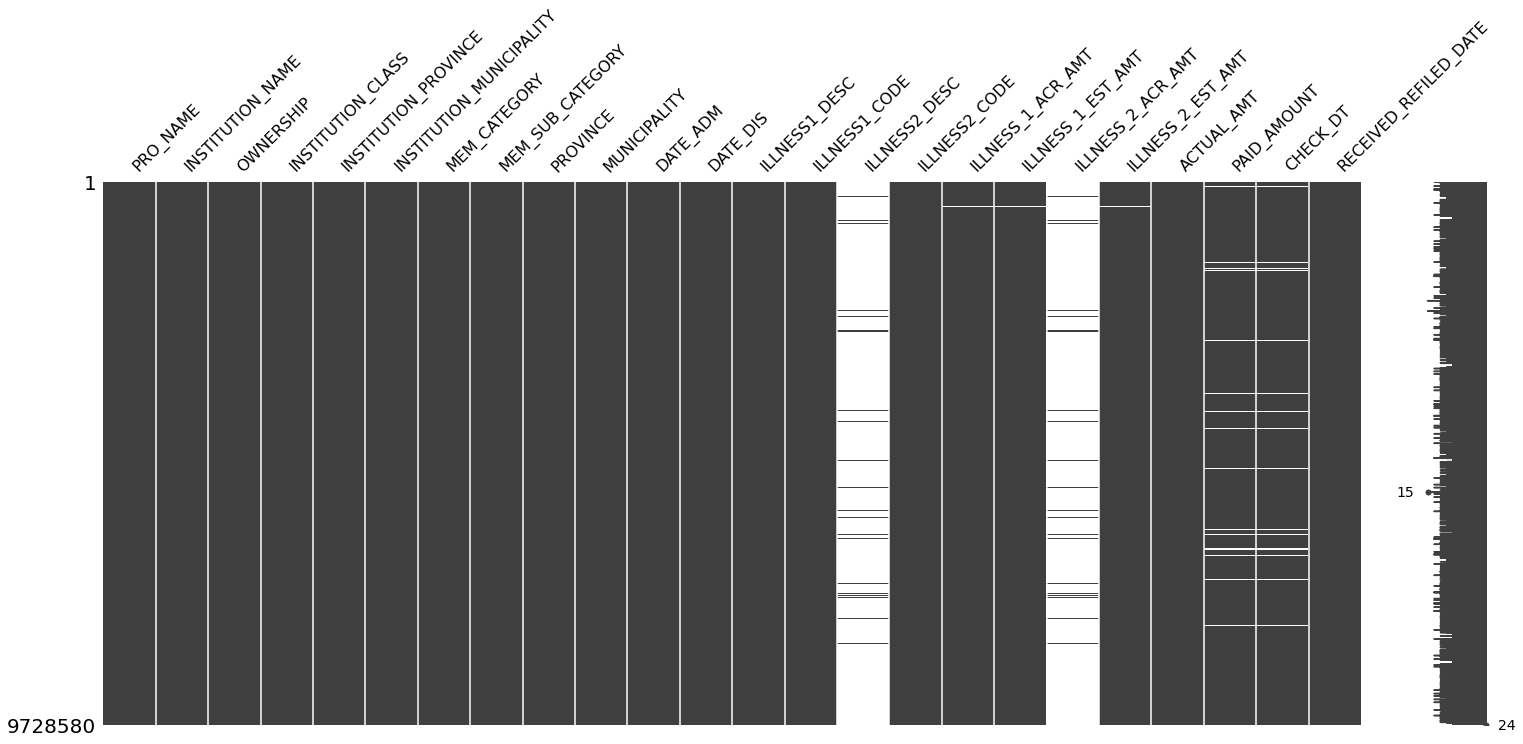

In [94]:
msno.matrix(df1)

<AxesSubplot:>

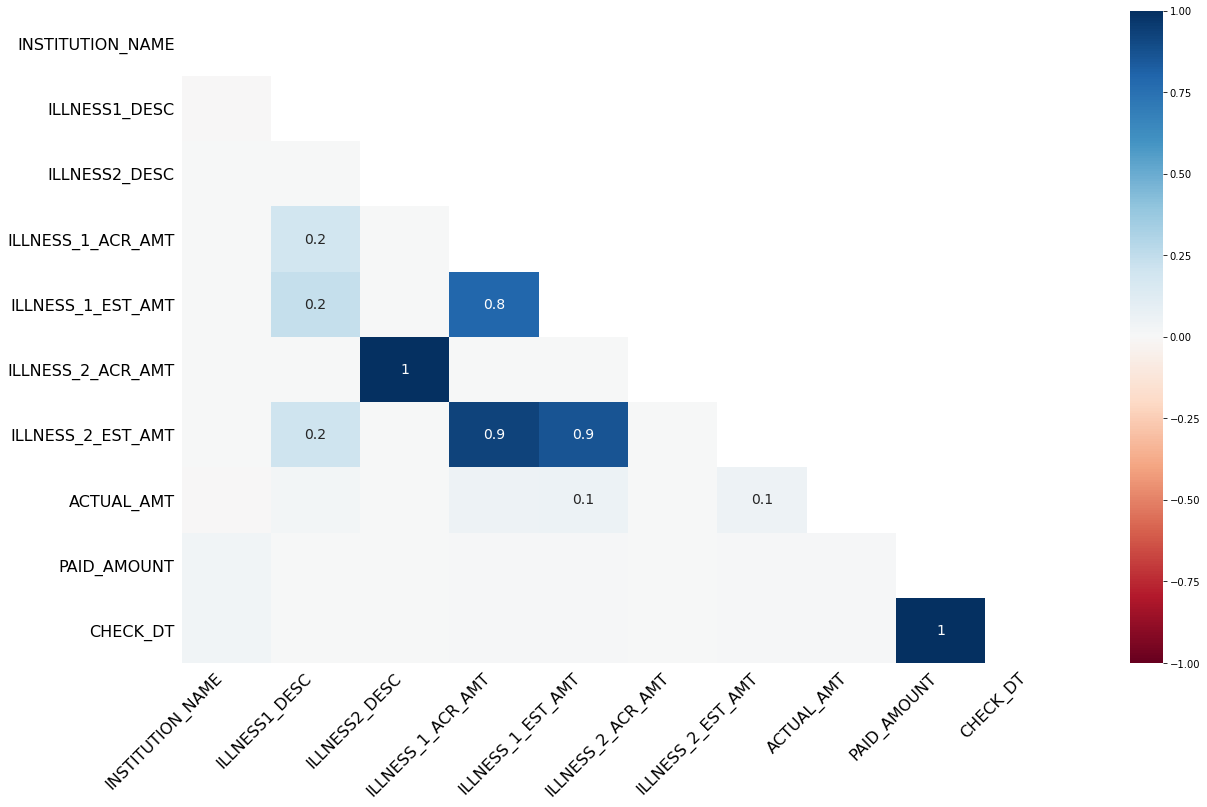

In [95]:
msno.heatmap(df1)

In [ ]:
msno.dendrogram(df1)

In [9]:
histog_ph = pg.Histogram()

In [79]:
# import cairosvg
# import cairocffi
# histog_ph.title = 'Actual Amount'
# histog_ph.add('A', df1['ACTUAL_AMT'].head(1000))
# histog_ph

In [92]:
df2 = df1[(df1['ACTUAL_AMT'] >= 0) & (df1['ACTUAL_AMT'] < 10000)]['ACTUAL_AMT'].to_frame() \
.set_axis(['ACTUAL_AMT'], axis=1, inplace=False)

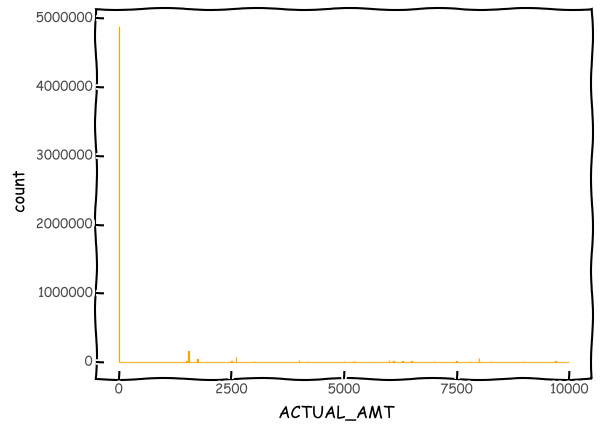

<ggplot: (164066855415)>

In [93]:
# reference: https://plotnine.readthedocs.io/en/stable/generated/plotnine.geoms.geom_histogram.html
p = ggplot(aes(x='ACTUAL_AMT'), data=df2)
p + geom_histogram(binwidth=10, 
                   fill='blue',     # fill color
                   colour='orange', # outline colod
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + theme_xkcd()

In [99]:
# df3 = df1['ILLNESS1_DESC'].head(10000)
pd.options.display.max_colwidth = 200
df3.head(30)

Unnamed: 0
0                                                                                                                                                                                 NORMAL NEWBORN CARE PACKAGE
1                                         OPEN TREATMENT OF INTERTROCHANTERIC, PERTROCHANTERIC, OR SUBTROCHANTERIC FEMORAL FRACTURE; W/ INTRAMEDULLARY IMPLANT, W/ OR W/O INTERLOCKING SCREWS AND/OR CERCLAGE
2     COMMUNITY-ACQUIRED PNEUMONIA III (THIS CLASSIFICATION UTILIZED THE AMERICAN THORACIC SOCIETY RECOMMENDATION. THIS IS EQUIVALENT TO CAP, MODERATE RISK IN THE PHILIPPINE CLINICAL PRACTICE GUIDELINES...
3                                                                                                                                                                                       ACUTE GASTROENTERITIS
4     MULTIPLE SUPERFICIAL INJURIES, UNSPECIFIED; MULTIPLE ABRASIONS NOS; MULTIPLE NONTHERMAL BLISTERS NOS; MULTIPLE BRUISES NOS; MULTIPLE CONTUSIONS NOS; MULTIPLE H

### Testing for Unpaid Claims Processing

In [53]:
df2 = df1[df1['CHECK_DT'].isna() & ~df1['RECEIVED_REFILED_DATE'].isna()]
df2.head()

,PRO_NAME,INSTITUTION_NAME,OWNERSHIP,INSTITUTION_CLASS,INSTITUTION_PROVINCE,INSTITUTION_MUNICIPALITY,MEM_CATEGORY,MEM_SUB_CATEGORY,PROVINCE,MUNICIPALITY,...,ILLNESS2_DESC,ILLNESS2_CODE,ILLNESS_1_ACR_AMT,ILLNESS_1_EST_AMT,ILLNESS_2_ACR_AMT,ILLNESS_2_EST_AMT,ACTUAL_AMT,PAID_AMOUNT,CHECK_DT,RECEIVED_REFILED_DATE
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
13,PRO IVA,"ST. JOHN THE BAPTIST MEDICAL CENTER, INC.",CORPORATE,LEVEL 1 HOSPITAL,LAGUNA,CALAMBA,DIRECT CONTRIBUTOR,EMPLOYED PRIVATE,LAGUNA,CALAMBA,...,NaN,-1,11000.0000,11000.0000,NaN,0.0000,41663.6700,11000.0000,NaN,2020-10-30
34,PRO XI,SOUTHERN PHILIPPINES MEDICAL CENTER,DOH,LEVEL 3 HOSPITAL,DAVAO DEL SUR,DAVAO CITY,INFORMAL ECONOMY,SELF-EARNING INDIVIDUAL,DAVAO DEL SUR,DAVAO CITY,...,NaN,-1,5450.0000,5450.0000,NaN,0.0000,16350.0000,NaN,NaN,2020-07-08
36,PRO I,STO. CRISTO MILAGROSO HOSPITAL,CORPORATE,LEVEL 1 HOSPITAL,ILOCOS SUR,SINAIT,DIRECT CONTRIBUTOR,EMPLOYED PRIVATE,ILOCOS SUR,SINAIT,...,NaN,-1,11000.0000,11000.0000,NaN,0.0000,13907.0000,NaN,NaN,2020-09-01
53,PRO IVA,QUEZON MEDICAL CENTER,PROVINCIAL,LEVEL 2 HOSPITAL,QUEZON,LUCENA CITY,INFORMAL ECONOMY,INFORMAL SECTOR,QUEZON,LUCENA CITY,...,NaN,-1,2750.0000,2950.0000,NaN,0.0000,2750.0000,2750.0000,NaN,2020-03-31
65,PRO NCR CENTRAL,ST. LUKE'S MEDICAL CENTER,CORPORATE,LEVEL 3 HOSPITAL,SECOND DISTRICT,QUEZON CITY,LIFETIME MEMBER,LIFETIME MEMBER,SECOND DISTRICT,QUEZON CITY,...,NaN,-1,3409.0000,3409.0000,NaN,0.0000,19561.7400,NaN,NaN,2020-11-18


In [49]:
df2[df2['ACTUAL_AMT'].isna()].isna().sum()

PRO_NAME                      0
INSTITUTION_NAME              2
OWNERSHIP                     0
INSTITUTION_CLASS             0
INSTITUTION_PROVINCE          0
INSTITUTION_MUNICIPALITY      0
MEM_CATEGORY                  0
MEM_SUB_CATEGORY              0
PROVINCE                      0
MUNICIPALITY                  0
DATE_ADM                      0
DATE_DIS                      0
ILLNESS1_DESC                 7
ILLNESS1_CODE                 0
ILLNESS2_DESC               245
ILLNESS2_CODE                 0
ILLNESS_1_ACR_AMT            36
ILLNESS_1_EST_AMT            36
ILLNESS_2_ACR_AMT           245
ILLNESS_2_EST_AMT            36
ACTUAL_AMT                  245
PAID_AMOUNT                 245
CHECK_DT                    245
RECEIVED_REFILED_DATE         0
dtype: int64

In [50]:
len(df2[df2['ACTUAL_AMT'].isna()])

245

In [54]:
df2['ACTUAL_AMT'].fillna(df2['ILLNESS_1_ACR_AMT'], inplace=True)

In [55]:
df2[df2['ACTUAL_AMT'].isna()].isna().sum()

PRO_NAME                     0
INSTITUTION_NAME             2
OWNERSHIP                    0
INSTITUTION_CLASS            0
INSTITUTION_PROVINCE         0
INSTITUTION_MUNICIPALITY     0
MEM_CATEGORY                 0
MEM_SUB_CATEGORY             0
PROVINCE                     0
MUNICIPALITY                 0
DATE_ADM                     0
DATE_DIS                     0
ILLNESS1_DESC                7
ILLNESS1_CODE                0
ILLNESS2_DESC               36
ILLNESS2_CODE                0
ILLNESS_1_ACR_AMT           36
ILLNESS_1_EST_AMT           36
ILLNESS_2_ACR_AMT           36
ILLNESS_2_EST_AMT           36
ACTUAL_AMT                  36
PAID_AMOUNT                 36
CHECK_DT                    36
RECEIVED_REFILED_DATE        0
dtype: int64

In [56]:
len(df2[df2['ACTUAL_AMT'].isna()])

36

In [58]:
df2.groupby(['PRO_NAME'])['ACTUAL_AMT'].agg(['mean', 'median', 'count', 'min', 'max'])

,mean,median,count,min,max
PRO_NAME,,,,,
PRO ARMM,12237.6610,8174.0000,15255,0.0000,856264.4700
PRO CAR,2145476.0664,2710.0000,23774,0.0000,40250924161.0000
PRO CARAGA,21713.2814,8000.0000,16179,0.0000,49069826.0000
PRO I,17388.9854,8401.5300,47386,-37245.1200,1316979.0600
PRO II,20984.6153,10540.0000,48640,0.0000,18122900.0000
PRO IIIA,25752.4858,6990.0000,88801,0.0000,237932767.7100
PRO IIIB,24390.1182,9000.0000,50066,0.0000,6019582.0000
PRO IVA,29014.2575,8000.0000,59872,0.0000,8687684.2500
PRO IVB,22923.7722,7845.0000,71255,0.0000,145100600.0000


In [66]:
del[df1, df2]
gc.collect()
gc.collect()

0